# Цепь Макрова

In [2]:
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from scipy.stats import entropy
from typing import Optional, Dict, Any
import warnings

import sys
import os
sys.path.append(os.path.abspath('/Users/v.makshanchikov/Documents/Python Proj/ВКР Магистратура/stochastic_models/markov_chain'))
from markov_chain_model import build_transition_matrix, stationary_distribution, compute_transition_metrics

def distribution_distance(pi_true: np.ndarray, pi_noisy: np.ndarray, metric: str = 'tv') -> float:
    """Расстояние между стационарными распределениями."""
    if metric == 'tv':   # total variation
        return 0.5 * np.sum(np.abs(pi_true - pi_noisy))
    elif metric == 'kl':
        eps = 1e-12
        p = pi_true + eps
        q = pi_noisy + eps
        p /= p.sum()
        q /= q.sum()
        return entropy(p, q)
    else:
        raise ValueError(f"Неизвестная метрика: {metric}")

def trim_transition_matrix(P: np.ndarray, min_state: int = None, max_state: int = None):
    """Обрезает матрицу до заданного диапазона состояний (включительно)."""
    if min_state is None:
        min_state = np.where(P.sum(axis=1) > 0)[0].min()
    if max_state is None:
        max_state = np.where(P.sum(axis=1) > 0)[0].max()
    return P[min_state:max_state+1, min_state:max_state+1], min_state, max_state

In [3]:
results_dir = Path("/Users/v.makshanchikov/Documents/Python Proj/ВКР Магистратура/inferense_datasets/groundingdino_results_parr")
original_counts = np.load(results_dir / "original.npy")
total_frames = len(original_counts)

# Построение эталонной матрицы переходов
max_state_orig = int(np.max(original_counts))  # максимальное число людей в оригинале
P_orig = build_transition_matrix(original_counts, max_state=max_state_orig)
pi_orig = stationary_distribution(P_orig)

print("=== Оригинальные данные (baseline) ===")
print(f"Диапазон состояний: 0..{max_state_orig}")
print(f"Доля ненулевых строк матрицы: {np.mean(P_orig.sum(axis=1) > 0):.2%}")
print(f"Среднее количество людей в стац. режиме: {np.sum(pi_orig * np.arange(len(pi_orig))):.2f}")
print()

=== Оригинальные данные (baseline) ===
Диапазон состояний: 0..39
Доля ненулевых строк матрицы: 82.50%
Среднее количество людей в стац. режиме: 18.18



/Users/v.makshanchikov/Documents/Python Proj/ВКР Магистратура/stochastic_models/markov_chain/markov_chain_model.py:42: UserWarning: Состояния без переходов: [ 0  1  2  3  4  6 38]. Их строки останутся нулевыми.
  warnings.warn(f"Состояния без переходов: {np.where(zero_rows)[0]}. Их строки останутся нулевыми.")


In [5]:
import warnings
warnings.filterwarnings('ignore')

noise_types = {
    "gaussian": {"pattern": r"gaussian_var_([0-9.]+)\.npy", "param_name": "variance"},
    "poisson":  {"pattern": r"poisson_scale_([0-9.]+)\.npy", "param_name": "scale"},
    "salt_pepper": {"pattern": r"salt_pepper_prob_([0-9.]+)\.npy", "param_name": "probability"},
    "speckle":  {"pattern": r"speckle_scale_([0-9.]+)\.npy", "param_name": "scale"}
}

# Хранилища результатов
metrics_results = {nt: [] for nt in noise_types}
pi_metrics = {nt: [] for nt in noise_types}   # расстояния между стац. распределениями
mean_counts = {nt: [] for nt in noise_types}   # среднее количество людей

# Для каждого шума
for noise_name, info in noise_types.items():
    pattern = info["pattern"]
    files = list(results_dir.glob(f"{noise_name}_*.npy"))
    print(f"Обработка {noise_name.upper()}... найдено {len(files)} файлов")
    
    for f in files:
        match = re.search(pattern, f.name)
        if not match:
            continue
        param = float(match.group(1))
        counts = np.load(f)
        if len(counts) != total_frames:
            print(f"  Предупреждение: {f.name} имеет длину {len(counts)} != {total_frames}")
            continue
        
        # Строим матрицу переходов для шумных данных, но приводим к размеру эталонной (max_state_orig+1)
        # Для состояний, превышающих max_state_orig, они будут отброшены (обрежем до эталонного размера)
        # Для безопасности: если в шумных данных появились значения > max_state_orig, увеличим матрицу?
        # Лучше расширить матрицу до максимума из {max_state_orig, max(counts)}.
        max_state_noisy = int(np.max(counts))
        max_state_combined = max(max_state_orig, max_state_noisy)
        P_noisy_full = build_transition_matrix(counts, max_state=max_state_combined)
        
        # Приводим к размеру эталонной матрицы: обрезаем или дополняем нулями
        if max_state_combined > max_state_orig:
            # Расширяем эталонную матрицу нулями справа и снизу
            P_orig_padded = np.zeros((max_state_combined+1, max_state_combined+1))
            P_orig_padded[:max_state_orig+1, :max_state_orig+1] = P_orig
            P_true = P_orig_padded
        else:
            P_true = P_orig
            P_noisy = P_noisy_full[:max_state_orig+1, :max_state_orig+1]
        
        # Вычисляем метрики
        mae = compute_transition_metrics(P_true, P_noisy, metric='mae')
        mse = compute_transition_metrics(P_true, P_noisy, metric='mse')
        kl = compute_transition_metrics(P_true, P_noisy, metric='kl')
        
        # Стационарное распределение для шумной матрицы
        pi_noisy = stationary_distribution(P_noisy)
        # Приводим pi_noisy к размеру pi_orig (если размеры разные)
        if len(pi_noisy) < len(pi_orig):
            pi_noisy_padded = np.zeros(len(pi_orig))
            pi_noisy_padded[:len(pi_noisy)] = pi_noisy
            pi_noisy = pi_noisy_padded
        elif len(pi_noisy) > len(pi_orig):
            pi_orig_padded = np.zeros(len(pi_noisy))
            pi_orig_padded[:len(pi_orig)] = pi_orig
            pi_orig_use = pi_orig_padded
        else:
            pi_orig_use = pi_orig
        tv_dist = distribution_distance(pi_orig_use, pi_noisy, metric='tv')
        kl_dist = distribution_distance(pi_orig_use, pi_noisy, metric='kl')
        
        # Среднее количество людей в состоянии
        mean_cnt = np.sum(pi_noisy * np.arange(len(pi_noisy)))
        
        metrics_results[noise_name].append({
            "param": param,
            "MAE": mae,
            "MSE": mse,
            "KL": kl,
            "TV_pi": tv_dist,
            "KL_pi": kl_dist,
            "mean_count": mean_cnt
        })
    
    # Сортировка по параметру
    metrics_results[noise_name].sort(key=lambda x: x["param"])
    print(f"  Завершено, обработано {len(metrics_results[noise_name])} файлов\n")

Обработка GAUSSIAN... найдено 10 файлов
  Завершено, обработано 10 файлов

Обработка POISSON... найдено 10 файлов
  Завершено, обработано 10 файлов

Обработка SALT_PEPPER... найдено 10 файлов
  Завершено, обработано 10 файлов

Обработка SPECKLE... найдено 12 файлов
  Завершено, обработано 12 файлов



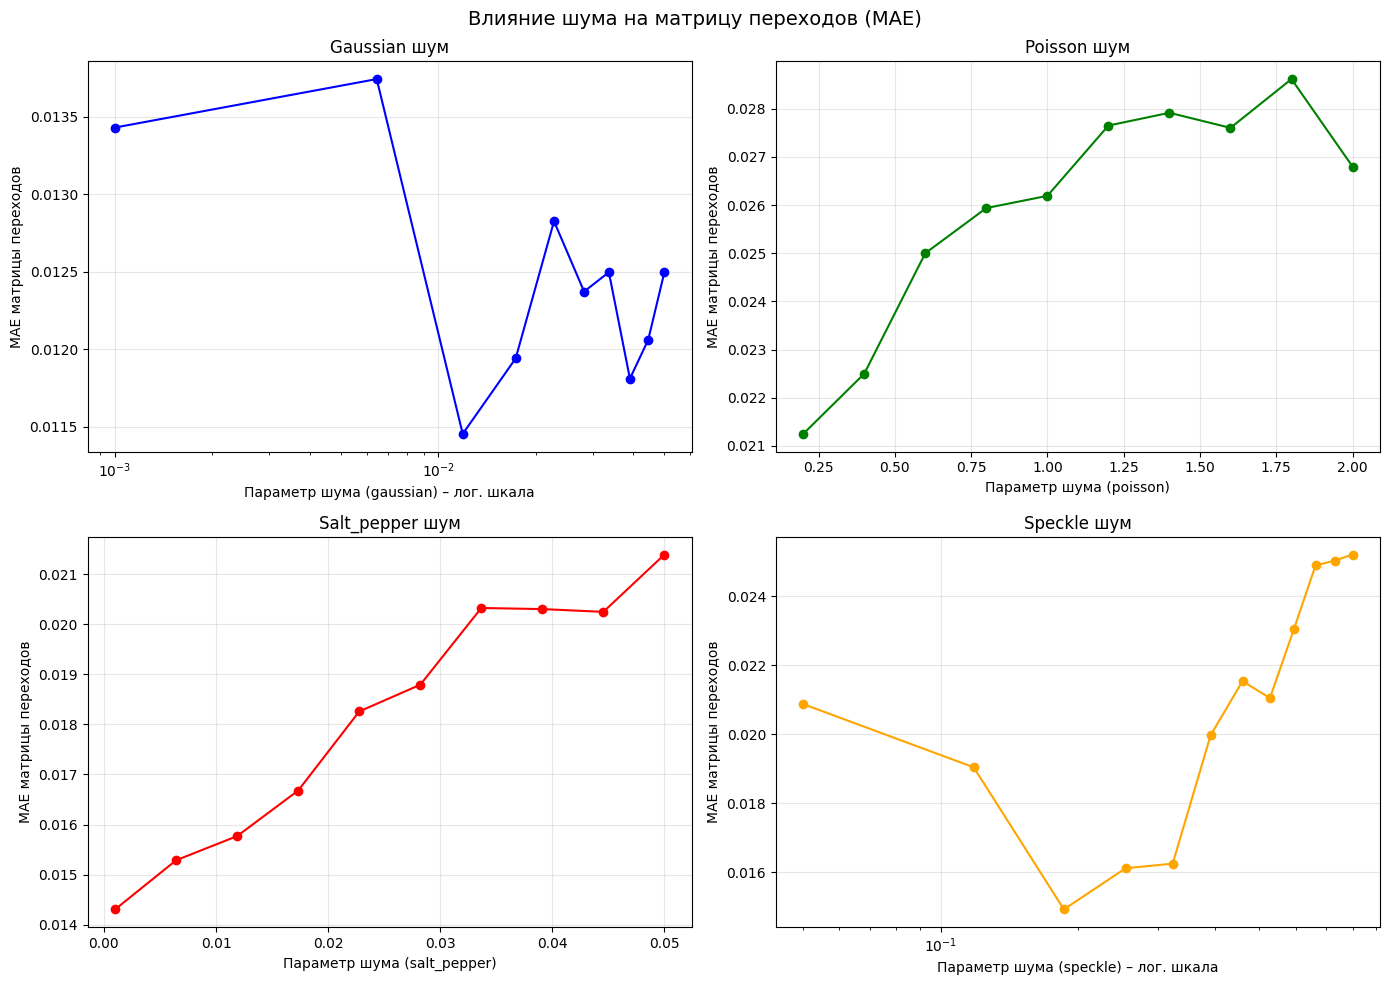

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Влияние шума на матрицу переходов (MAE)", fontsize=14)

colors = {"gaussian": "blue", "poisson": "green", "salt_pepper": "red", "speckle": "orange"}

for ax, (noise_name, data) in zip(axes.flatten(), metrics_results.items()):
    if not data:
        ax.set_title(f"{noise_name.capitalize()} – нет данных")
        continue
    params = [d["param"] for d in data]
    mae_vals = [d["MAE"] for d in data]
    ax.plot(params, mae_vals, 'o-', color=colors.get(noise_name, "black"), label="MAE")
    ax.set_xlabel(f"Параметр шума ({noise_name})")
    ax.set_ylabel("MAE матрицы переходов")
    ax.set_title(f"{noise_name.capitalize()} шум")
    ax.grid(True, alpha=0.3)
    if noise_name in ["gaussian", "speckle"] and len(params) > 1 and max(params)/min(params) > 10:
        ax.set_xscale('log')
        ax.set_xlabel(f"Параметр шума ({noise_name}) – лог. шкала")
plt.tight_layout()
plt.show()

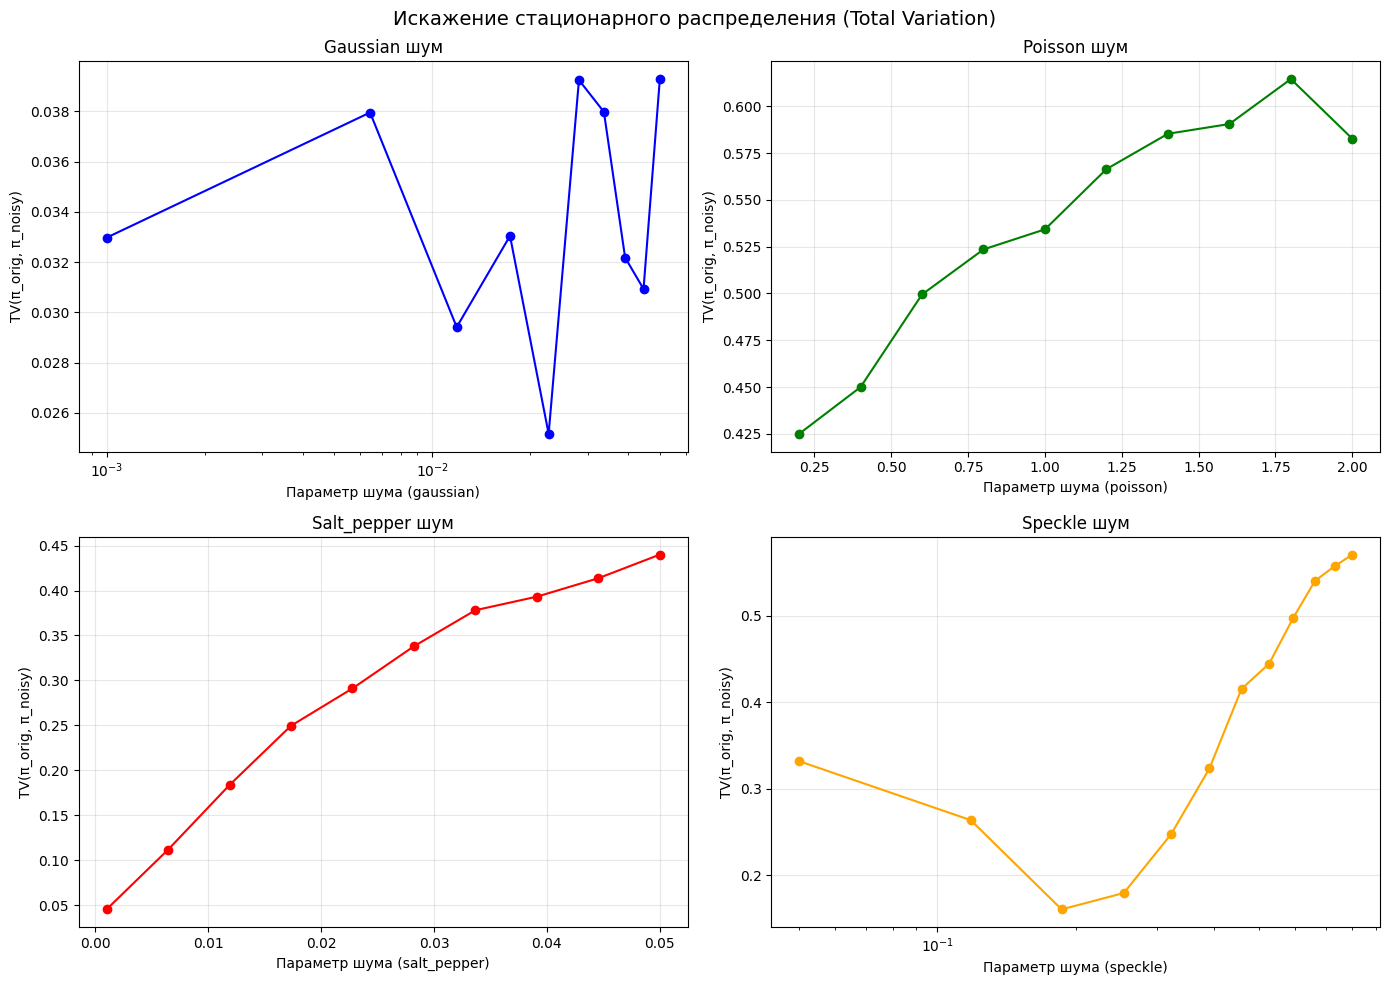

In [7]:
# Графики для расстояний между стационарными распределениями
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle("Искажение стационарного распределения (Total Variation)", fontsize=14)
for ax, (noise_name, data) in zip(axes2.flatten(), metrics_results.items()):
    if not data:
        ax.set_title(f"{noise_name.capitalize()} – нет данных")
        continue
    params = [d["param"] for d in data]
    tv_vals = [d["TV_pi"] for d in data]
    ax.plot(params, tv_vals, 'o-', color=colors.get(noise_name, "black"), label="TV distance")
    ax.set_xlabel(f"Параметр шума ({noise_name})")
    ax.set_ylabel("TV(π_orig, π_noisy)")
    ax.set_title(f"{noise_name.capitalize()} шум")
    ax.grid(True, alpha=0.3)
    if noise_name in ["gaussian", "speckle"] and len(params) > 1 and max(params)/min(params) > 10:
        ax.set_xscale('log')
plt.tight_layout()
plt.show()

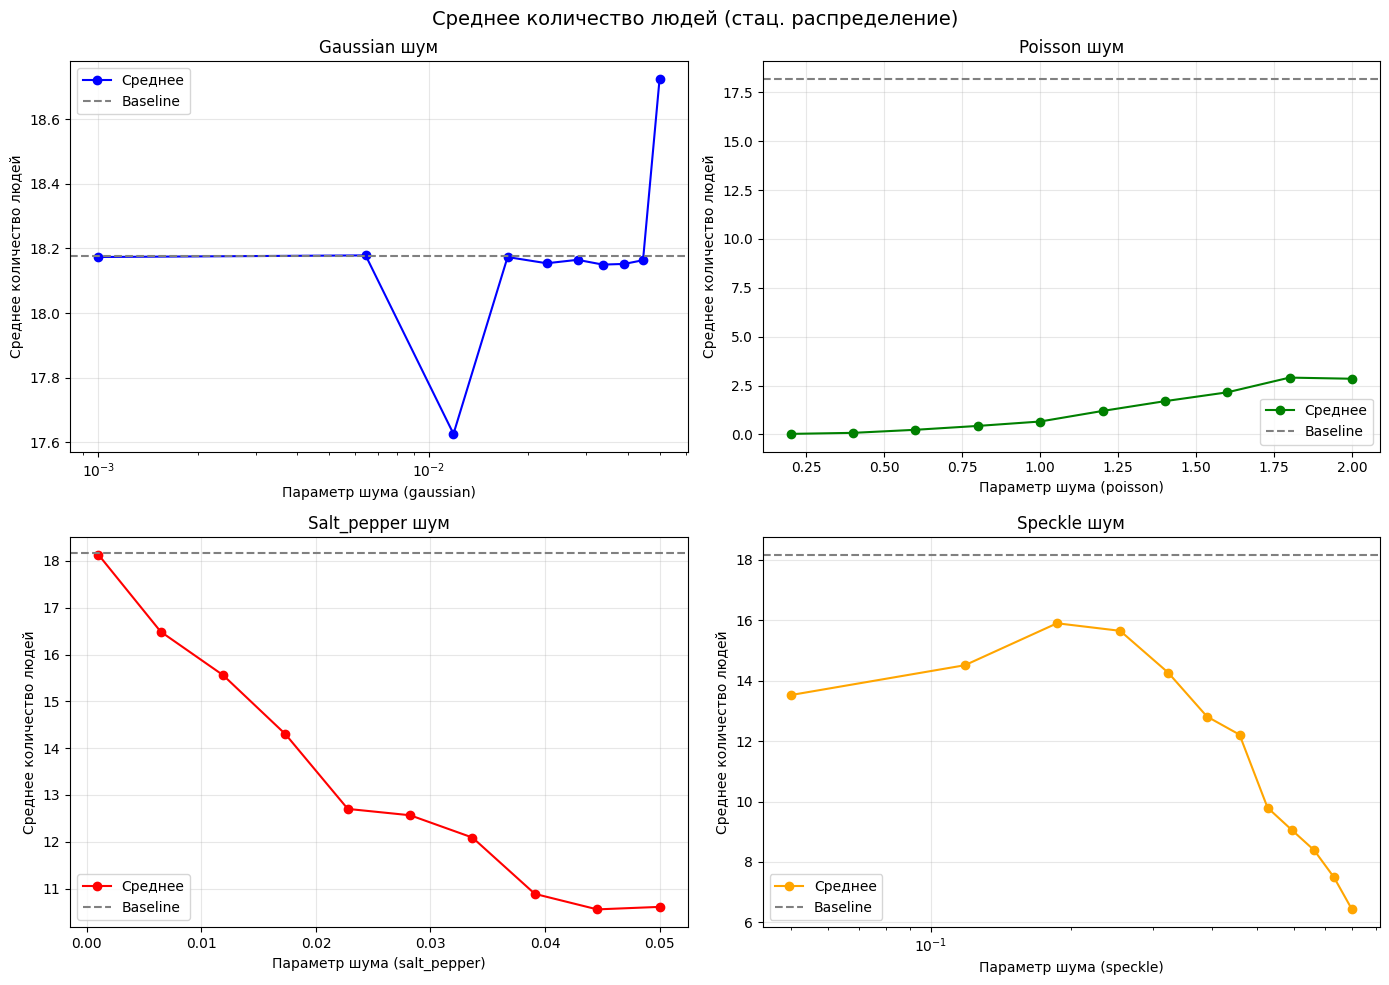

In [8]:
fig3, axes3 = plt.subplots(2, 2, figsize=(14, 10))
fig3.suptitle("Среднее количество людей (стац. распределение)", fontsize=14)
for ax, (noise_name, data) in zip(axes3.flatten(), metrics_results.items()):
    if not data:
        ax.set_title(f"{noise_name.capitalize()} – нет данных")
        continue
    params = [d["param"] for d in data]
    mean_vals = [d["mean_count"] for d in data]
    ax.plot(params, mean_vals, 'o-', color=colors.get(noise_name, "black"), label="Среднее")
    ax.axhline(y=np.sum(pi_orig * np.arange(len(pi_orig))), color='gray', linestyle='--', label="Baseline")
    ax.set_xlabel(f"Параметр шума ({noise_name})")
    ax.set_ylabel("Среднее количество людей")
    ax.set_title(f"{noise_name.capitalize()} шум")
    ax.grid(True, alpha=0.3)
    if noise_name in ["gaussian", "speckle"] and len(params) > 1 and max(params)/min(params) > 10:
        ax.set_xscale('log')
    ax.legend()
plt.tight_layout()
plt.show()

In [9]:
def visualize_noise_impact(noise_name: str, param_values: list, results_dir: Path, 
                           P_orig: np.ndarray, pi_orig: np.ndarray, max_state_orig: int):
    """Для заданного типа шума и списка параметров рисует тепловые карты и гистограммы."""
    pattern = noise_types[noise_name]["pattern"]
    files = list(results_dir.glob(f"{noise_name}_*.npy"))
    selected_data = []
    for param in param_values:
        for f in files:
            match = re.search(pattern, f.name)
            if match and abs(float(match.group(1)) - param) < 1e-6:
                counts = np.load(f)
                P_noisy_full = build_transition_matrix(counts, max_state=int(np.max(counts)))
                # Обрезаем до диапазона, где есть переходы (или до исходного)
                P_noisy_trim, min_s, max_s = trim_transition_matrix(P_noisy_full)
                pi_noisy = stationary_distribution(P_noisy_full)
                selected_data.append((param, counts, P_noisy_trim, min_s, max_s, pi_noisy))
                break
    if not selected_data:
        print(f"Не найдены файлы для {noise_name} с параметрами {param_values}")
        return
    
    n_params = len(selected_data)
    fig, axes = plt.subplots(2, n_params, figsize=(5*n_params, 8))
    fig.suptitle(f"Влияние {noise_name} шума на марковскую цепь", fontsize=14)
    
    for idx, (param, _, P_trim, min_s, max_s, pi_noisy) in enumerate(selected_data):
        # Тепловая карта матрицы переходов
        ax1 = axes[0, idx]
        sns.heatmap(P_trim, cmap='YlOrRd', ax=ax1, cbar=idx==0,
                    xticklabels=range(min_s, max_s+1), yticklabels=range(min_s, max_s+1))
        ax1.set_title(f"Параметр = {param:.4f}\n(состояния {min_s}–{max_s})")
        ax1.set_xlabel("Состояние t+1")
        ax1.set_ylabel("Состояние t")
        
        # Стационарное распределение
        ax2 = axes[1, idx]
        # Обрезаем pi до того же диапазона, что и матрица
        pi_vis = pi_noisy[min_s:max_s+1]
        states_vis = np.arange(min_s, max_s+1)
        ax2.bar(states_vis, pi_vis, color='steelblue', alpha=0.7, edgecolor='black')
        ax2.set_xlabel("Количество людей")
        ax2.set_ylabel("Вероятность")
        ax2.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

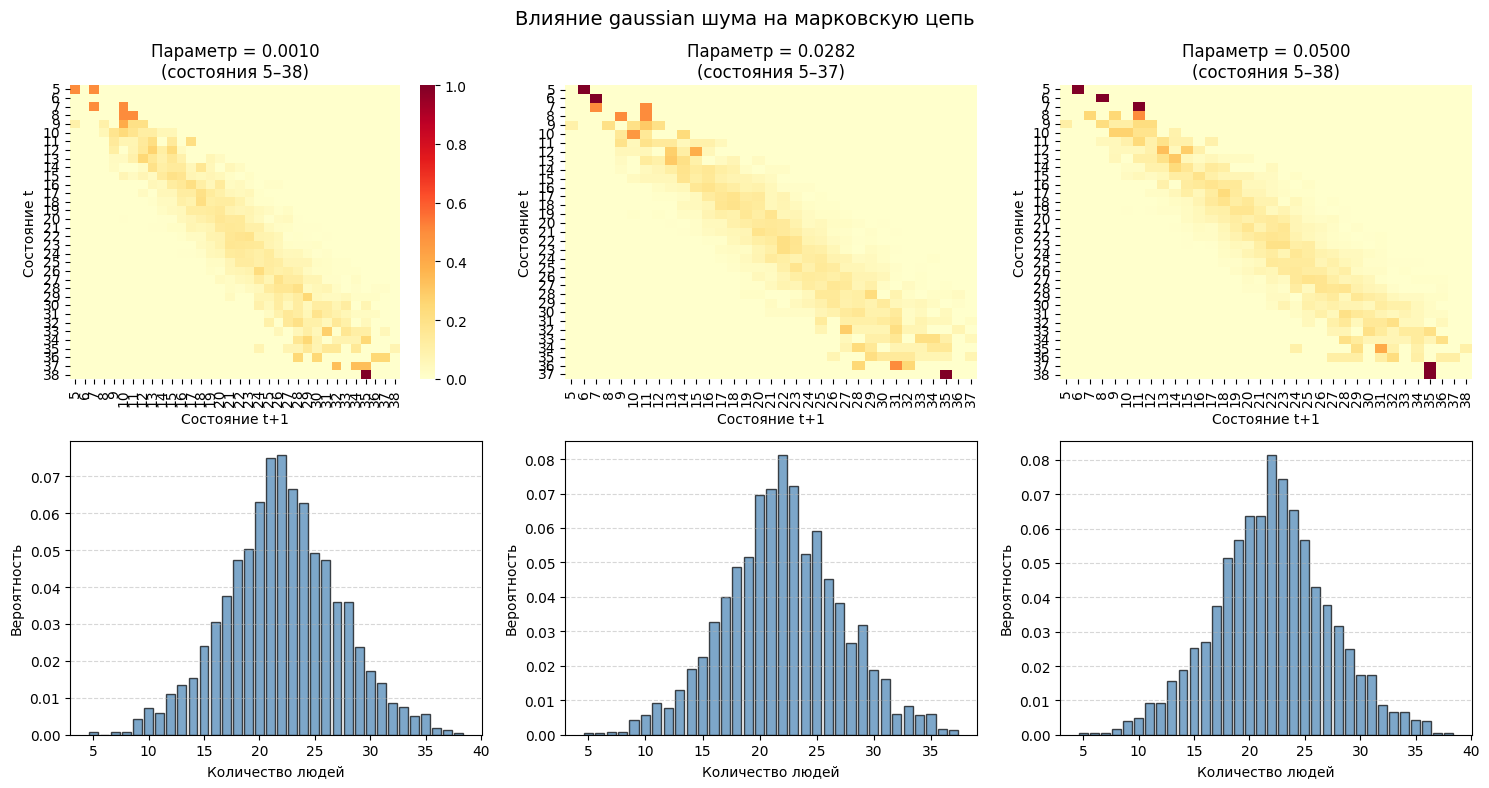

In [10]:
# Пример: для гауссовского шума выберем минимальный, средний и максимальный параметр
gaussian_data = metrics_results["gaussian"]
if gaussian_data:
    params_g = [d["param"] for d in gaussian_data]
    if len(params_g) >= 3:
        selected_params = [params_g[0], params_g[len(params_g)//2], params_g[-1]]
    else:
        selected_params = params_g
    visualize_noise_impact("gaussian", selected_params, results_dir, P_orig, pi_orig, max_state_orig)

In [11]:
print("\n=== Сводная таблица метрик ===")
for noise_name, data in metrics_results.items():
    df = pd.DataFrame(data)
    df = df.round(5)
    print(f"\n{noise_name.upper()}:")
    print(df.to_string(index=False))


=== Сводная таблица метрик ===

GAUSSIAN:
  param     MAE     MSE      KL   TV_pi   KL_pi  mean_count
0.00100 0.01343 0.00375 3.80047 0.03298 0.01699    18.17352
0.00644 0.01374 0.00433 4.17089 0.03796 0.01884    18.17845
0.01189 0.01145 0.00239 2.55868 0.02942 0.01307    17.62641
0.01733 0.01194 0.00342 3.38101 0.03305 0.01535    18.17332
0.02278 0.01283 0.00447 4.04717 0.02517 0.01279    18.15413
0.02822 0.01237 0.00363 3.33474 0.03925 0.01916    18.16474
0.03367 0.01250 0.00347 3.24315 0.03798 0.01758    18.14999
0.03911 0.01181 0.00286 2.52195 0.03219 0.01502    18.15208
0.04456 0.01206 0.00382 3.39313 0.03093 0.01487    18.16362
0.05000 0.01250 0.00389 3.81504 0.03929 0.01681    18.72380

POISSON:
 param     MAE     MSE      KL   TV_pi    KL_pi  mean_count
   0.2 0.02125 0.00507 2.03248 0.42500 20.89980     0.02500
   0.4 0.02250 0.00617 3.13596 0.45000 21.99841     0.07774
   0.6 0.02500 0.00676 5.26823 0.49948 22.81661     0.23432
   0.8 0.02594 0.00669 5.98176 0.52353 22.94335